In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from keras_models import AddPositionEmbedding
from torch_models import ConvNet, CNNViT, make_loader, predict_probabilities
torch.set_num_threads(2)
_, _, test = split_paths()
x_test = load_array(test[0])
test_loader = make_loader(*test)
keras_cnn = tf.keras.models.load_model(ROOT / "models" / "keras_cnn.keras")
keras_hybrid = tf.keras.models.load_model(ROOT / "models" / "keras_cnn_vit.keras")
pytorch_cnn = ConvNet()
pytorch_cnn.load_state_dict(torch.load(ROOT / "models" / "pytorch_cnn.pth", map_location="cpu", weights_only=True))
pytorch_hybrid = CNNViT(pytorch_cnn)
pytorch_hybrid.load_state_dict(torch.load(ROOT / "models" / "pytorch_cnn_vit.pth", map_location="cpu", weights_only=True))
probabilities = {
    "Keras CNN": keras_cnn.predict(x_test, verbose=0).reshape(-1),
    "PyTorch CNN": predict_probabilities(pytorch_cnn, test_loader),
    "Keras CNN-ViT": keras_hybrid.predict(x_test, verbose=0)[:, 1],
    "PyTorch CNN-ViT": predict_probabilities(pytorch_hybrid, test_loader),
}
print("Models evaluated on the identical test images:", len(test[1]))


Models evaluated on the identical test images: 72


In [3]:
metrics = {name: evaluate_binary(test[1], probs) for name, probs in probabilities.items()}
table = pd.DataFrame(metrics).T[["n_test", "accuracy", "precision", "recall", "f1", "roc_auc", "log_loss"]]
print(table.round(4).to_string())
table.to_csv(ROOT / "results" / "final_comparison.csv")


                n_test  accuracy precision    recall        f1   roc_auc  log_loss
Keras CNN           72  0.930556       1.0  0.861111  0.925373  0.968364  0.427624
PyTorch CNN         72  0.861111       1.0  0.722222   0.83871  0.925154  0.451605
Keras CNN-ViT       72  0.930556  0.969697  0.888889  0.927536  0.970679  0.198067
PyTorch CNN-ViT     72  0.888889    0.9375  0.833333  0.882353   0.91821  0.288944


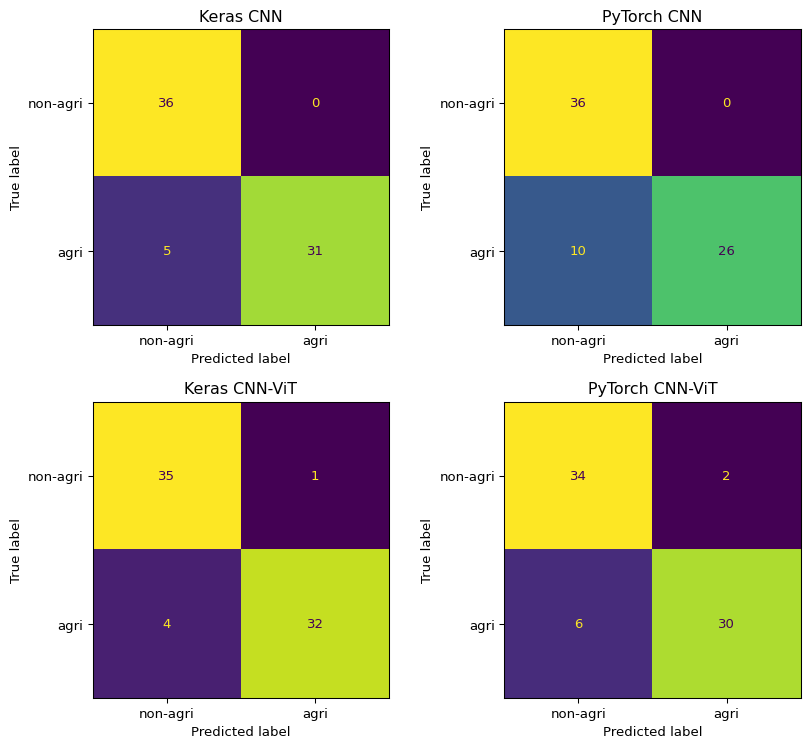

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for axis, (name, result) in zip(axes.flat, metrics.items()):
    ConfusionMatrixDisplay(np.asarray(result["confusion_matrix"]), display_labels=("non-agri", "agri")).plot(ax=axis, colorbar=False)
    axis.set_title(name)
plt.tight_layout()
plt.show()


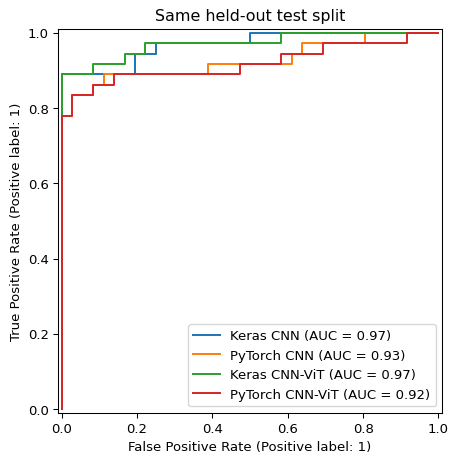

In [5]:
fig, axis = plt.subplots(figsize=(6, 5))
for name, probs in probabilities.items():
    RocCurveDisplay.from_predictions(test[1], probs, ax=axis, name=name)
axis.set_title("Same held-out test split")
plt.tight_layout()
plt.show()
